# Centralidades de Hubs y Autoridad

La siguiente es una red de colaboración en la cual los nodos representan investigadores y están unidos mediante una arista si son coautores en un mismo trabajo.


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import plotly.graph_objects as go
import plotly.io as pio
import ipywidgets as widgets
from IPython.display import display
import matplotlib
from matplotlib import colors as mcolors

pio.renderers.default = "vscode"
plt.set_cmap("rainbow")

<Figure size 640x480 with 0 Axes>

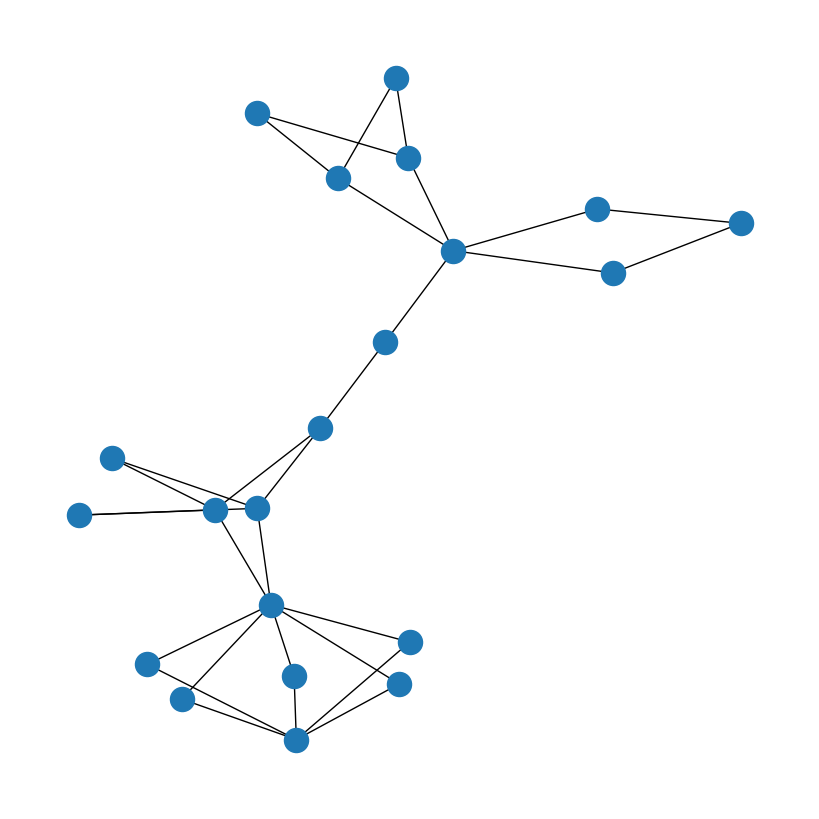

In [2]:
stark_targaryen = ['Rickard','Lyarra','Aerys','Rhaella','Catelyn','Ned','Lyanna','Rhaegar','Elia','Viserys','Daenerys',
                   'Brandon', 'Benjen', 'Robb', 'Sansa', 'Arya', 'Bran', 'Rickon', 'Rhaenys', 'Aegon','Jon']

parents = [('Rickard','Ned'),('Rickard','Lyanna'),('Rickard','Brandon'),('Rickard','Benjen'),
           ('Lyarra','Ned'),('Lyarra','Lyanna'),('Lyarra','Brandon'),('Lyarra','Benjen'),
           ('Aerys','Rhaegar'),('Aerys','Viserys'),('Aerys','Daenerys'),
           ('Rhaella','Rhaegar'),('Rhaella','Viserys'),('Rhaella','Daenerys'),
           ('Catelyn','Robb'),('Catelyn','Sansa'), ('Catelyn','Arya'), ('Catelyn','Bran'), ('Catelyn','Rickon'),
           ('Ned','Robb'),('Ned','Sansa'), ('Ned','Arya'), ('Ned','Bran'), ('Ned','Rickon'),
           ('Rhaegar','Rhaenys'), ('Rhaegar','Aegon'),('Elia','Rhaenys'), ('Elia','Aegon'),
           ('Lyanna','Jon'),('Rhaegar','Jon')]

G1 = nx.Graph()
G1.add_nodes_from(stark_targaryen)
G1.add_edges_from(parents)

plt.figure(figsize=[8, 8])
layout = nx.kamada_kawai_layout(G1)
nx.draw(G1, layout)

# Actividad


In [3]:
def safe_katz_centrality(G, alpha=0.5, step=0.01):
    while alpha > 0:
        try:
            return nx.katz_centrality(G, alpha=alpha), alpha
        except Exception:
            alpha -= step

    raise ValueError("Katz centrality did not converge for any positive alpha.")

deg_centralidades = nx.degree_centrality(G1)
eig_centralidades = nx.eigenvector_centrality(G1, tol=0.0001)
katz_centralidades, katz_alpha = safe_katz_centrality(G1, alpha=0.1)
print(f"Convergio con un alpha={katz_alpha:.4f}")
pg_centralidades = nx.pagerank(G1)
hubs_centralidades, auth_centralidades = nx.hits(G1)
clos_centralidades = nx.closeness_centrality(G1)
btw_centralidades = nx.betweenness_centrality(G1)


def sum1_dict(d):
    s = sum(abs(v) for v in d.values())
    return {k: (v / s if s != 0 else 0.0) for k, v in d.items()}


deg_centralidades = sum1_dict(deg_centralidades)
eig_centralidades = sum1_dict(eig_centralidades)
katz_centralidades = sum1_dict(katz_centralidades)
pg_centralidades = sum1_dict(pg_centralidades)
hubs_centralidades = sum1_dict(hubs_centralidades)
auth_centralidades = sum1_dict(auth_centralidades)
clos_centralidades = sum1_dict(clos_centralidades)
btw_centralidades = sum1_dict(btw_centralidades)

eig_sizes = np.array([eig_centralidades[n] for n in G1])
deg_colors = np.array([deg_centralidades[i] for i in G1])
pg_sizes = np.array([pg_centralidades[n] for n in G1])
katz_colors = np.array([katz_centralidades[i] for i in G1])
hubs_colors = np.array([hubs_centralidades[i] for i in G1])
auth_colors = np.array([auth_centralidades[i] for i in G1])
clos_colors = np.array([clos_centralidades[i] for i in G1])
btw_colors = np.array([btw_centralidades[i] for i in G1])

metrics = {
    "Degree": np.asarray(deg_colors, dtype=float),
    "Eigenvector": np.asarray(eig_sizes, dtype=float),
    "Katz": np.asarray(katz_colors, dtype=float),
    "PageRank": np.asarray(pg_sizes, dtype=float),
    "Hubs": np.asarray(hubs_colors, dtype=float),
    "Authorities": np.asarray(auth_colors, dtype=float),
    "Closeness": np.asarray(clos_colors, dtype=float),
    "Betweenness": np.asarray(btw_colors, dtype=float),
}

# if is directed, we can also calculate in-degree centrality
if G1.is_directed():
    deg_in_centralidades = nx.in_degree_centrality(G1)
    deg_out_centralidades = nx.out_degree_centrality(G1)
    deg_in_centralidades = sum1_dict(deg_in_centralidades)
    deg_out_centralidades = sum1_dict(deg_out_centralidades)
    deg_in_colors = np.array([deg_in_centralidades[i] for i in G1])
    deg_out_colors = np.array([deg_out_centralidades[i] for i in G1])
    metrics["InDegree"] = np.asarray(deg_in_colors, dtype=float)
    metrics["OutDegree"] = np.asarray(deg_out_colors, dtype=float)

Convergio con un alpha=0.1000


In [4]:
k = 10

top_deg = [n for n, v in sorted(
    deg_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_eig = [n for n, v in sorted(
    eig_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_katz = [n for n, v in sorted(
    katz_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_pg = [n for n, v in sorted(
    pg_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_hubs = [n for n, v in sorted(
    hubs_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_auth = [n for n, v in sorted(
    auth_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_clos = [n for n, v in sorted(
    clos_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_btw = [n for n, v in sorted(
    btw_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]

if G1.is_directed():
    top_deg_in = [n for n, v in sorted(
        deg_in_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]
    top_deg_out = [n for n, v in sorted(
        deg_out_centralidades.items(), key=lambda kv: kv[1], reverse=True)[:k]]

In [5]:
def plot_network(
    G,
    metrics,
    metric="Degree",
    topk=10,
    largest_first=True,
    layout="kamada_kawai",
    colorscale="Turbo",
    renderer="vscode",   # or "notebook_connected"
    interactive=False,   # default static
):
    nodes = list(G.nodes())
    N = len(nodes)

    # Validate and normalize metrics
    m = {}
    for name, arr in metrics.items():
        a = np.asarray(arr, dtype=float)
        if len(a) != N:
            raise ValueError(f"Metric '{name}' has length {len(a)} but graph has {N} nodes.")
        m[name] = a

    if metric not in m:
        raise ValueError(f"`metric` must be one of: {list(m.keys())}")

    # Fixed layout
    pos = nx.spring_layout(G, seed=7) if layout == "spring" else nx.kamada_kawai_layout(G)

    node_x = np.array([pos[n][0] for n in nodes])
    node_y = np.array([pos[n][1] for n in nodes])

    # Edges
    edge_x, edge_y = [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    # Arrow annotations for directed graphs
    directed_annotations = []
    if G.is_directed():
        span = max(node_x.max() - node_x.min(), node_y.max() - node_y.min())
        pad = 0.02 * span if span > 0 else 0.03

        for u, v in G.edges():
            x0, y0 = pos[u]
            x1, y1 = pos[v]
            dx, dy = x1 - x0, y1 - y0
            L = np.hypot(dx, dy)
            if L == 0:
                continue

            ux, uy = dx / L, dy / L
            ax = x0 + ux * pad
            ay = y0 + uy * pad
            xh = x1 - ux * pad
            yh = y1 - uy * pad

            directed_annotations.append(dict(
                x=xh, y=yh, ax=ax, ay=ay,
                xref="x", yref="y", axref="x", ayref="y",
                text="", showarrow=True,
                arrowhead=3, arrowsize=1.0, arrowwidth=1.0,
                arrowcolor="rgba(95,110,130,0.55)"
            ))

    global_max = max(arr.max() for arr in m.values())

    # Hover with all metrics for each node
    all_hover = []
    metric_order = list(m.keys())
    for i, n in enumerate(nodes):
        lines = [f"<b>{n}</b>"]
        for metric_name in metric_order:
            lines.append(f"{metric_name}: {m[metric_name][i]:.4f}")
        all_hover.append("<br>".join(lines))

    def topk_mask(vals, k, largest=True):
        k = max(1, min(int(k), len(vals)))
        idx = np.argsort(vals)
        pick = idx[-k:] if largest else idx[:k]
        mask = np.zeros(len(vals), dtype=bool)
        mask[pick] = True
        return mask

    def build_fig(metric_name, k, largest):
        vals = m[metric_name]
        mask = topk_mask(vals, k, largest)

        vmin, vmax = vals.min(), vals.max()
        sizes = 16 + 34 * (vals - vmin) / (vmax - vmin + 1e-12)
        order_txt = "largest to smallest" if largest else "smallest to largest"

        fig = go.Figure()

        # edges
        fig.add_trace(go.Scatter(
            x=edge_x, y=edge_y, mode="lines",
            line=dict(width=0.8, color="rgba(95,110,130,0.35)"),
            hoverinfo="none", showlegend=False
        ))

        # non-top-k
        fig.add_trace(go.Scatter(
            x=node_x[~mask], y=node_y[~mask],
            mode="markers+text",
            text=[str(n) for n, keep in zip(nodes, mask) if not keep],
            textposition="top center",
            textfont=dict(family="Helvetica", size=11, color="#7A8797"),
            hovertext=[h for h, keep in zip(all_hover, mask) if not keep],
            hoverinfo="text",
            marker=dict(
                size=sizes[~mask],
                color="#D9DEE5",
                opacity=0.45,
                line=dict(width=1.8, color="white"),
            ),
            showlegend=False
        ))

        # top-k
        fig.add_trace(go.Scatter(
            x=node_x[mask], y=node_y[mask],
            mode="markers+text",
            text=[str(n) for n, keep in zip(nodes, mask) if keep],
            textposition="top center",
            textfont=dict(family="Helvetica", size=11, color="#1F2937"),
            hovertext=[h for h, keep in zip(all_hover, mask) if keep],
            hoverinfo="text",
            marker=dict(
                size=sizes[mask],
                color=vals[mask],
                colorscale=colorscale,
                cmin=0,
                cmax=global_max,
                opacity=0.98,
                line=dict(width=2.2, color="white"),
                colorbar=dict(
                    title=dict(text=metric_name, side="right", font=dict(family="Helvetica", size=13)),
                    thickness=36,
                    len=0.72,
                    y=0.5,
                    x=1.02,
                    outlinewidth=0,
                    borderwidth=0,
                    bgcolor="rgba(0,0,0,0)",
                    tickfont=dict(family="Helvetica", size=11),
                )
            ),
            showlegend=False
        ))

        fig.update_layout(
            title=dict(
                text=f"<b>Red de Coautorías</b><br>Top {k} by {metric_name} from {order_txt}",
                font=dict(family="Helvetica", size=24, color="#111827")
            ),
            paper_bgcolor="white",
            plot_bgcolor="white",
            font=dict(family="Helvetica", size=12, color="#334155"),
            margin=dict(l=10, r=130, t=90, b=10),
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            height=740,
            dragmode="pan",
            annotations=directed_annotations if G.is_directed() else [],
        )
        return fig

    # Static by default
    if not interactive:
        fig = build_fig(metric, max(1, min(int(topk), N)), largest_first)
        fig.show(renderer=renderer, config={"staticPlot": True, "displaylogo": False})
        return fig

    # Interactive controls
    metric_dd = widgets.Dropdown(
        options=list(m.keys()),
        value=metric,
        description="Metric:",
        layout=widgets.Layout(width="260px")
    )
    k_slider = widgets.IntSlider(
        value=max(1, min(int(topk), N)),
        min=1, max=N, step=1,
        description="Top k:",
        layout=widgets.Layout(width="340px")
    )
    order_btn = widgets.ToggleButtons(
        options=[("Largest first", True), ("Smallest first", False)],
        value=largest_first,
        description="Order:",
        layout=widgets.Layout(width="430px")
    )

    out = widgets.Output()

    def redraw(*_):
        fig = build_fig(metric_dd.value, k_slider.value, order_btn.value)
        out.clear_output(wait=True)
        with out:
            fig.show(renderer=renderer, config={"displaylogo": False, "scrollZoom": True})

    metric_dd.observe(redraw, names="value")
    k_slider.observe(redraw, names="value")
    order_btn.observe(redraw, names="value")

    display(widgets.VBox([widgets.HBox([metric_dd, k_slider]), order_btn, out]))
    redraw()


In [6]:
from IPython.display import clear_output
clear_output(wait=True)


In [7]:
# tabla

def tabla(top_pos, digits, optional_col_name = None, optional_col_values = None):
    df = (
        pd.DataFrame({
            "node": top_pos,
            "Degree": [deg_centralidades[n] for n in top_pos],
            "Eigenvector": [eig_centralidades[n] for n in top_pos],
            "Katz": [katz_centralidades[n] for n in top_pos],
            "PageRank": [pg_centralidades[n] for n in top_pos],
            "Hubs": [hubs_centralidades[n] for n in top_pos],
            "Authorities": [auth_centralidades[n] for n in top_pos],
            "Closeness": [clos_centralidades[n] for n in top_pos],
            "Betweenness": [btw_centralidades[n] for n in top_pos],
                **({optional_col_name: optional_col_values} if optional_col_name and optional_col_values else {})
        })
        .reset_index(drop=True)
    )

    


    if G1.is_directed():
        df["InDegree"] = [deg_in_centralidades[n] for n in top_pos]
        df["OutDegree"] = [deg_out_centralidades[n] for n in top_pos]
        

    display(
        df.style.format(
            {
                "Eigenvector": f"{{:.{digits}f}}",
                "Degree": f"{{:.{digits}f}}",
                "PageRank": f"{{:.{digits}f}}",
                "Katz": f"{{:.{digits}f}}",
                "Hubs": f"{{:.{digits}f}}",
                "Authorities": f"{{:.{digits}f}}",
                "Closeness": f"{{:.{digits}f}}",
                "Betweenness": f"{{:.{digits}f}}",
                
                **({f"{optional_col_name}": f"{{:.{digits}f}}" if optional_col_name else {}}),
                 **({"InDegree": f"{{:.{digits}f}}", "OutDegree": f"{{:.{digits}f}}" } if G1.is_directed() else {})
                    
            }
        )
    )



        
    return df

In [8]:
def plot_ego(
    G,
    center,
    metrics,
    metric="Degree",
    radius=2,
    max_radius_user=4,
    layout="kamada_kawai",
    seed=7,
    renderer="vscode",
    interactive=False,          # default = static
    show_colored_labels=True,  # new: labels for nodes within current radius
):
    if center not in G:
        raise ValueError(f"{center!r} is not in graph")

    nodes = list(G.nodes())
    N = len(nodes)

    m = {}
    for k, arr in metrics.items():
        a = np.asarray(arr, dtype=float)
        if len(a) != N:
            raise ValueError(f"Metric '{k}' has length {len(a)} but graph has {N} nodes.")
        m[k] = a
    if metric not in m:
        raise ValueError(f"`metric` must be one of: {list(m.keys())}")

    all_dist = nx.single_source_shortest_path_length(G, center)
    max_available = max(all_dist.values()) if all_dist else 0
    max_r = int(max(0, min(max_radius_user, max_available)))

    pos = nx.spring_layout(G, seed=seed, iterations=300) if layout == "spring" else nx.kamada_kawai_layout(G)
    node_x = np.array([pos[n][0] for n in nodes])
    node_y = np.array([pos[n][1] for n in nodes])

    ex, ey = [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        ex += [x0, x1, None]
        ey += [y0, y1, None]

    # Arrows if directed
    directed_annotations = []
    if G.is_directed():
        span = max(node_x.max() - node_x.min(), node_y.max() - node_y.min())
        pad = 0.02 * span if span > 0 else 0.03
        for u, v in G.edges():
            x0, y0 = pos[u]
            x1, y1 = pos[v]
            dx, dy = x1 - x0, y1 - y0
            L = np.hypot(dx, dy)
            if L == 0:
                continue
            ux, uy = dx / L, dy / L
            directed_annotations.append(dict(
                x=x1 - ux * pad, y=y1 - uy * pad,
                ax=x0 + ux * pad, ay=y0 + uy * pad,
                xref="x", yref="y", axref="x", ayref="y",
                text="", showarrow=True, arrowhead=3, arrowsize=1.0, arrowwidth=1.0,
                arrowcolor="rgba(70,80,100,0.55)"
            ))

    dist = nx.single_source_shortest_path_length(G, center, cutoff=max_r)

    cmap = matplotlib.colormaps["Blues"]
    if max_r > 0:
        stops = np.linspace(0.95, 0.35, max_r + 1)
        center_color = mcolors.to_hex(cmap(stops[0]))
        blues_by_d = {d: mcolors.to_hex(cmap(stops[d])) for d in range(1, max_r + 1)}
    else:
        center_color = mcolors.to_hex(cmap(0.95))
        blues_by_d = {}
    gray_out = "rgba(165,165,165,0.60)"

    metric_names = list(m.keys())
    hover_all = []
    for i, n in enumerate(nodes):
        lines = [f"<b>{n}</b>", f"dist({center})={all_dist.get(n,'∞')}"]
        lines += [f"{mk}: {m[mk][i]:.4f}" for mk in metric_names]
        hover_all.append("<br>".join(lines))

    def make_sizes(metric_name):
        vals = m[metric_name]
        vmin, vmax = vals.min(), vals.max()
        z = (vals - vmin) / (vmax - vmin + 1e-12)
        s = 14 + 20 * z
        return np.array([34 if n == center else float(si) for n, si in zip(nodes, s)])

    def make_title(r):
        SG = nx.ego_graph(G, center, radius=r)
        nn, ne = SG.number_of_nodes(), SG.number_of_edges()
        dens = nx.density(SG) if nn > 1 else 0.0
        cum = [len(nx.ego_graph(G, center, radius=d).nodes()) for d in range(r + 1)]
        neigh = [cum[d] - cum[d - 1] for d in range(1, r + 1)]
        return (
            f"<span style='font-size:22px; font-family:Helvetica; color:#1F2937;'><b>Nodo {center}</b> · radio {r}</span><br>"
            f"<span style='font-size:13px; color:#4B5563;'>Nodos <b>{nn}</b> · Aristas <b>{ne}</b> · Densidad <b>{dens:.3f}</b></span><br>"
            f"<span style='font-size:12px; color:#6B7280;'>Vecinos por distancia: <b>{neigh}</b></span>"
        )

    def build_fig(metric_name, r, show_labels):
        r = int(max(0, min(r, max_r)))
        sizes = make_sizes(metric_name)

        colors, opac = [], []
        for n in nodes:
            d = dist.get(n, None)
            if n == center:
                colors.append(center_color); opac.append(1.0)
            elif d is not None and d <= r and d >= 1:
                colors.append(blues_by_d[d]); opac.append(0.96)
            else:
                colors.append(gray_out); opac.append(0.55)

        labels = []
        if show_labels:
            for n in nodes:
                d = all_dist.get(n, None)
                labels.append(str(n) if (d is not None and 1 <= d <= r) else "")
            node_mode = "markers+text"
        else:
            labels = None
            node_mode = "markers"

        fig = go.Figure()
        fig.add_trace(go.Scatter(
            x=ex, y=ey, mode="lines",
            line=dict(width=0.8, color="rgba(70,80,100,0.20)"),
            hoverinfo="none", showlegend=False
        ))
        fig.add_trace(go.Scatter(
            x=node_x, y=node_y, mode=node_mode,
            text=labels, textposition="top center",
            textfont=dict(size=10, color="#1F2937", family="Helvetica"),
            hovertext=hover_all, hoverinfo="text",
            marker=dict(size=sizes, color=colors, opacity=opac, line=dict(width=2.0, color="white")),
            showlegend=False
        ))

        cx, cy = pos[center]
        fig.add_trace(go.Scatter(
            x=[cx], y=[cy], mode="text", text=[str(center)], textposition="top center",
            textfont=dict(size=20, color="#1F2937", family="Helvetica"),
            hoverinfo="skip", showlegend=False
        ))

        fig.update_layout(
            title=make_title(r),
            template="simple_white",
            paper_bgcolor="#FFFFFF",
            plot_bgcolor="#FFFFFF",
            font=dict(family="Helvetica", size=13, color="#1F2937"),
            height=780, margin=dict(l=20, r=20, t=95, b=20),
            xaxis=dict(visible=False), yaxis=dict(visible=False),
            dragmode="pan",
            annotations=directed_annotations if G.is_directed() else []
        )
        return fig

    if not interactive:
        fig = build_fig(metric, radius, show_colored_labels)
        fig.show(renderer=renderer, config={"staticPlot": True, "displaylogo": False})
        return fig

    metric_dd = widgets.Dropdown(
        options=list(m.keys()), value=metric, description="Metric:", layout=widgets.Layout(width="260px")
    )
    r_slider = widgets.IntSlider(
        value=max(0, min(int(radius), max_r)), min=0, max=max_r, step=1,
        description="Radius:", layout=widgets.Layout(width="340px")
    )
    labels_cb = widgets.Checkbox(
        value=show_colored_labels, description="Label colored neighbors"
    )
    out = widgets.Output()

    def redraw(*_):
        fig = build_fig(metric_dd.value, r_slider.value, labels_cb.value)
        out.clear_output(wait=True)
        with out:
            fig.show(renderer=renderer, config={"displaylogo": False, "scrollZoom": True})

    metric_dd.observe(redraw, names="value")
    r_slider.observe(redraw, names="value")
    labels_cb.observe(redraw, names="value")

    display(widgets.VBox([widgets.HBox([metric_dd, r_slider, labels_cb]), out]))
    redraw()


In [9]:
def network_differences(
    G,
    metrics,                   # dict: {"Degree": array, ...} aligned with list(G.nodes())
    metric_a="Hubs",
    metric_b="Authorities",
    case="a-b top k",          # "a-b top k" | "a-b bottom k" | "abs(a-b) top k" | "abs(a-b) bottom k"
    topk=10,
    layout="kamada_kawai",
    renderer="vscode",
    interactive=False,         # default static
):
    nodes = list(G.nodes())
    N = len(nodes)

    # Validate metrics
    m = {}
    for name, arr in metrics.items():
        a = np.asarray(arr, dtype=float)
        if len(a) != N:
            raise ValueError(f"Metric '{name}' has length {len(a)} but graph has {N} nodes.")
        m[name] = a
    metric_names = list(m.keys())

    if metric_a not in m or metric_b not in m:
        raise ValueError(f"`metric_a` and `metric_b` must be in {metric_names}")
    if metric_a == metric_b:
        raise ValueError("metric_a and metric_b must be different.")

    # Layout once
    pos = nx.spring_layout(G, seed=7) if layout == "spring" else nx.kamada_kawai_layout(G)
    node_x = np.array([pos[n][0] for n in nodes])
    node_y = np.array([pos[n][1] for n in nodes])

    # Edges
    edge_x, edge_y = [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    # Precompute arrow annotations if directed
    directed_annotations = []
    if G.is_directed():
        span = max(node_x.max() - node_x.min(), node_y.max() - node_y.min())
        pad = 0.02 * span if span > 0 else 0.03

        for u, v in G.edges():
            x0, y0 = pos[u]
            x1, y1 = pos[v]
            dx, dy = x1 - x0, y1 - y0
            L = np.hypot(dx, dy)
            if L == 0:
                continue

            ux, uy = dx / L, dy / L
            ax = x0 + ux * pad
            ay = y0 + uy * pad
            xh = x1 - ux * pad
            yh = y1 - uy * pad

            directed_annotations.append(dict(
                x=xh, y=yh, ax=ax, ay=ay,
                xref="x", yref="y", axref="x", ayref="y",
                text="", showarrow=True,
                arrowhead=3, arrowsize=1.0, arrowwidth=1.0,
                arrowcolor="rgba(95,110,130,0.55)"
            ))

    valid_cases = ["a-b top k", "a-b bottom k", "abs(a-b) top k", "abs(a-b) bottom k"]

    def build_fig(ma, mb, c, k):
        if ma == mb:
            raise ValueError("metric_a and metric_b must be different.")
        if c not in valid_cases:
            raise ValueError(f"case must be one of: {valid_cases}")

        a = m[ma]
        b = m[mb]
        diff = a - b
        abs_diff = np.abs(diff)

        if c == "a-b top k":
            score, largest = diff, True
            color_vals, colorscale, color_title, cmid = diff, "RdBu", f"{ma} - {mb}", 0
        elif c == "a-b bottom k":
            score, largest = diff, False
            color_vals, colorscale, color_title, cmid = diff, "RdBu", f"{ma} - {mb}", 0
        elif c == "abs(a-b) top k":
            score, largest = abs_diff, True
            color_vals, colorscale, color_title, cmid = abs_diff, "Blues", f"|{ma} - {mb}|", None
        else:
            score, largest = abs_diff, False
            color_vals, colorscale, color_title, cmid = abs_diff, "Blues", f"|{ma} - {mb}|", None

        k = max(1, min(int(k), N))
        idx = np.argsort(score)
        pick = idx[-k:] if largest else idx[:k]
        mask = np.zeros(N, dtype=bool)
        mask[pick] = True

        svals = np.abs(score)
        smin, smax = svals.min(), svals.max()
        sizes = 16 + 34 * (svals - smin) / (smax - smin + 1e-12)

        hover = []
        for i, n in enumerate(nodes):
            hover.append(
                f"<b>{n}</b><br>"
                f"{ma}: {a[i]:.4f}<br>"
                f"{mb}: {b[i]:.4f}<br>"
                f"{ma}-{mb}: {diff[i]:.4f}<br>"
                f"|{ma}-{mb}|: {abs_diff[i]:.4f}"
            )

        fig = go.Figure()

        fig.add_trace(go.Scatter(
            x=edge_x, y=edge_y, mode="lines",
            line=dict(width=0.8, color="rgba(95,110,130,0.35)"),
            hoverinfo="none", showlegend=False
        ))

        fig.add_trace(go.Scatter(
            x=node_x[~mask], y=node_y[~mask],
            mode="markers+text",
            text=[str(n) for n, m_ in zip(nodes, mask) if not m_],
            textposition="top center",
            textfont=dict(family="Helvetica", size=11, color="#7A8797"),
            hovertext=[h for h, m_ in zip(hover, mask) if not m_],
            hoverinfo="text",
            marker=dict(
                size=sizes[~mask],
                color="#D9DEE5",
                opacity=0.45,
                line=dict(width=1.8, color="white"),
            ),
            showlegend=False
        ))

        marker_dict = dict(
            size=sizes[mask],
            color=color_vals[mask],
            colorscale=colorscale,
            opacity=0.98,
            line=dict(width=2.2, color="white"),
            colorbar=dict(
                title=dict(text=color_title, side="right", font=dict(family="Helvetica", size=13)),
                thickness=36, len=0.72, y=0.5, x=1.02,
                outlinewidth=0, borderwidth=0, bgcolor="rgba(0,0,0,0)",
                tickfont=dict(family="Helvetica", size=11),
            )
        )
        if cmid is not None:
            marker_dict["cmid"] = cmid

        fig.add_trace(go.Scatter(
            x=node_x[mask], y=node_y[mask],
            mode="markers+text",
            text=[str(n) for n, m_ in zip(nodes, mask) if m_],
            textposition="top center",
            textfont=dict(family="Helvetica", size=11, color="#1F2937"),
            hovertext=[h for h, m_ in zip(hover, mask) if m_],
            hoverinfo="text",
            marker=marker_dict,
            showlegend=False
        ))

        fig.update_layout(
            title=dict(
                text=f"<b>Difference Network</b><br>{c}  |  k={k}  |  {ma} vs {mb}",
                font=dict(family="Helvetica", size=22, color="#111827")
            ),
            paper_bgcolor="white",
            plot_bgcolor="white",
            font=dict(family="Helvetica", size=12, color="#334155"),
            margin=dict(l=10, r=130, t=90, b=10),
            xaxis=dict(visible=False),
            yaxis=dict(visible=False),
            height=740,
            dragmode="pan",
            annotations=directed_annotations if G.is_directed() else []
        )
        return fig

    if not interactive:
        fig = build_fig(metric_a, metric_b, case, topk)
        fig.show(renderer=renderer, config={"staticPlot": True, "displaylogo": False})
        return fig

    metric_a_dd = widgets.Dropdown(
        options=metric_names, value=metric_a, description="Metric a:", layout=widgets.Layout(width="250px")
    )
    metric_b_dd = widgets.Dropdown(
        options=metric_names, value=metric_b, description="Metric b:", layout=widgets.Layout(width="250px")
    )
    case_dd = widgets.Dropdown(
        options=valid_cases, value=case, description="Case:", layout=widgets.Layout(width="280px")
    )
    k_slider = widgets.IntSlider(
        value=max(1, min(int(topk), N)), min=1, max=N, step=1,
        description="Top k:", layout=widgets.Layout(width="320px")
    )

    out = widgets.Output()

    def redraw(*_):
        out.clear_output(wait=True)
        with out:
            if metric_a_dd.value == metric_b_dd.value:
                print("Choose different metrics for a and b.")
                return
            fig = build_fig(metric_a_dd.value, metric_b_dd.value, case_dd.value, k_slider.value)
            fig.show(renderer=renderer, config={"displaylogo": False, "scrollZoom": True})

    metric_a_dd.observe(redraw, names="value")
    metric_b_dd.observe(redraw, names="value")
    case_dd.observe(redraw, names="value")
    k_slider.observe(redraw, names="value")

    display(widgets.VBox([widgets.HBox([metric_a_dd, metric_b_dd, case_dd]), k_slider, out]))
    redraw()


## Grafica interactiva

In [10]:
_ = plot_network(G1, metrics, metric="PageRank", topk=10, interactive=True)

In [11]:
plot_ego(G1, center='Rickard', metrics=metrics, interactive=True, max_radius_user=6)

In [12]:
network_differences(G1, metrics, interactive=True)

## Top Grado

In [13]:
df_top_deg = tabla(top_deg, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness
0,Ned,0.1167,0.1533,0.0667,0.1026,0.2724,-0.0544,0.0570,0.1571
1,Catelyn,0.0833,0.1037,0.0560,0.0764,0.1843,-0.0368,0.0389,0.0088
2,Rhaegar,0.0833,0.0095,0.0556,0.0853,0.0161,-0.0032,0.0552,0.1828
3,Rickard,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924
4,Lyarra,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924
5,Aerys,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308
6,Rhaella,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308
7,Lyanna,0.0500,0.0548,0.0483,0.0484,0.0973,-0.0194,0.0634,0.1747
8,Elia,0.0333,0.0019,0.0418,0.0400,0.0031,-0.0006,0.0356,0.0009
9,Viserys,0.0333,0.0024,0.0427,0.0374,0.0038,-0.0008,0.0364,0.0006


In [14]:
_ = plot_network(G1, metrics, metric="Degree", topk=10, largest_first=True)

In [15]:
maxpos_node, maxpos_val = max(deg_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Degree", max_radius_user=6)

## Top Eigenvector

In [16]:
df_top_deg = tabla(top_eig, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness
0,Ned,0.1167,0.1533,0.0667,0.1026,0.2724,-0.0544,0.0570,0.1571
1,Catelyn,0.0833,0.1037,0.0560,0.0764,0.1843,-0.0368,0.0389,0.0088
2,Rickard,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924
3,Lyarra,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924
4,Robb,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053
5,Sansa,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053
6,Arya,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053
7,Bran,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053
8,Rickon,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053
9,Lyanna,0.0500,0.0548,0.0483,0.0484,0.0973,-0.0194,0.0634,0.1747


In [17]:
_ = plot_network(G1, metrics, metric="Eigenvector", topk=10, largest_first=True)

In [18]:
maxpos_node, maxpos_val = max(eig_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Eigenvector", max_radius_user=6)

## Diferencias grado - eigenvector

In [19]:
# top diferencias

diff = {n: (deg_centralidades[n] - eig_centralidades[n]) for n in G1.nodes()}
k = 10

top_pos = [n for n, v in sorted(diff.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_neg = [n for n, v in sorted(diff.items(), key=lambda kv: kv[1])[:k]]
closest0 = [n for n, v in sorted(diff.items(), key=lambda kv: abs(kv[1]))[:k]]
furthest = [n for n, v in sorted(diff.items(), key=lambda kv: abs(kv[1]), reverse=True)[:k]]

In [20]:
df_top_deg = tabla(top_pos, digits=4, optional_col_name="Top (Degree - Eigenvector)", optional_col_values=[diff[n] for n in top_pos])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Top (Degree - Eigenvector)
0,Rhaegar,0.0833,0.0095,0.0556,0.0853,0.0161,-0.0032,0.0552,0.1828,0.0738
1,Aerys,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308,0.0459
2,Rhaella,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308,0.0459
3,Elia,0.0333,0.0019,0.0418,0.0400,0.0031,-0.0006,0.0356,0.0009,0.0314
4,Viserys,0.0333,0.0024,0.0427,0.0374,0.0038,-0.0008,0.0364,0.0006,0.0309
5,Daenerys,0.0333,0.0024,0.0427,0.0374,0.0038,-0.0008,0.0364,0.0006,0.0309
6,Rhaenys,0.0333,0.0033,0.0430,0.0386,-0.0013,0.0046,0.0433,0.0158,0.0300
7,Aegon,0.0333,0.0033,0.0430,0.0386,-0.0013,0.0046,0.0433,0.0158,0.0300
8,Jon,0.0333,0.0183,0.0436,0.0353,-0.0077,0.0269,0.0600,0.1690,0.0150
9,Lyanna,0.0500,0.0548,0.0483,0.0484,0.0973,-0.0194,0.0634,0.1747,-0.0048


In [21]:
df_top_deg = tabla(top_neg, digits=4, optional_col_name="Bottom (Degree - Eigenvector)", optional_col_values=[diff[n] for n in top_neg])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Bottom (Degree - Eigenvector)
0,Robb,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,-0.0397
1,Sansa,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,-0.0397
2,Arya,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,-0.0397
3,Bran,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,-0.0397
4,Rickon,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,-0.0397
5,Ned,0.1167,0.1533,0.0667,0.1026,0.2724,-0.0544,0.0570,0.1571,-0.0366
6,Rickard,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924,-0.0207
7,Lyarra,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924,-0.0207
8,Catelyn,0.0833,0.1037,0.0560,0.0764,0.1843,-0.0368,0.0389,0.0088,-0.0203
9,Brandon,0.0333,0.0496,0.0439,0.0333,0.0881,-0.0176,0.0475,0.0004,-0.0163


In [22]:
df_top_deg = tabla(closest0, digits=4, optional_col_name="Top (Degree - Eigenvector)", optional_col_values=[diff[n] for n in closest0])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Top (Degree - Eigenvector)
0,Lyanna,0.0500,0.0548,0.0483,0.0484,0.0973,-0.0194,0.0634,0.1747,-0.0048
1,Jon,0.0333,0.0183,0.0436,0.0353,-0.0077,0.0269,0.0600,0.1690,0.0150
2,Brandon,0.0333,0.0496,0.0439,0.0333,0.0881,-0.0176,0.0475,0.0004,-0.0163
3,Benjen,0.0333,0.0496,0.0439,0.0333,0.0881,-0.0176,0.0475,0.0004,-0.0163
4,Catelyn,0.0833,0.1037,0.0560,0.0764,0.1843,-0.0368,0.0389,0.0088,-0.0203
5,Rickard,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924,-0.0207
6,Lyarra,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924,-0.0207
7,Rhaenys,0.0333,0.0033,0.0430,0.0386,-0.0013,0.0046,0.0433,0.0158,0.0300
8,Aegon,0.0333,0.0033,0.0430,0.0386,-0.0013,0.0046,0.0433,0.0158,0.0300
9,Viserys,0.0333,0.0024,0.0427,0.0374,0.0038,-0.0008,0.0364,0.0006,0.0309


In [23]:
df_top_deg = tabla(furthest, digits=4, optional_col_name="Furthest (Degree - Eigenvector)", optional_col_values=[diff[n] for n in furthest])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Furthest (Degree - Eigenvector)
0,Rhaegar,0.0833,0.0095,0.0556,0.0853,0.0161,-0.0032,0.0552,0.1828,0.0738
1,Aerys,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308,0.0459
2,Rhaella,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308,0.0459
3,Robb,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,-0.0397
4,Sansa,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,-0.0397
5,Arya,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,-0.0397
6,Bran,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,-0.0397
7,Rickon,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,-0.0397
8,Ned,0.1167,0.1533,0.0667,0.1026,0.2724,-0.0544,0.0570,0.1571,-0.0366
9,Elia,0.0333,0.0019,0.0418,0.0400,0.0031,-0.0006,0.0356,0.0009,0.0314


## Top Katz

In [24]:
df_top_deg = tabla(top_katz, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness
0,Ned,0.1167,0.1533,0.0667,0.1026,0.2724,-0.0544,0.0570,0.1571
1,Catelyn,0.0833,0.1037,0.0560,0.0764,0.1843,-0.0368,0.0389,0.0088
2,Rhaegar,0.0833,0.0095,0.0556,0.0853,0.0161,-0.0032,0.0552,0.1828
3,Rickard,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924
4,Lyarra,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924
5,Lyanna,0.0500,0.0548,0.0483,0.0484,0.0973,-0.0194,0.0634,0.1747
6,Aerys,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308
7,Rhaella,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308
8,Robb,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053
9,Sansa,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053


In [25]:
_ = plot_network(G1, metrics, metric="Katz", topk=10, largest_first=True)

In [26]:
maxpos_node, maxpos_val = max(katz_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Katz", max_radius_user=6)

## Top PageRank

In [27]:
df_top_deg = tabla(top_pg, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness
0,Ned,0.1167,0.1533,0.0667,0.1026,0.2724,-0.0544,0.0570,0.1571
1,Rhaegar,0.0833,0.0095,0.0556,0.0853,0.0161,-0.0032,0.0552,0.1828
2,Catelyn,0.0833,0.1037,0.0560,0.0764,0.1843,-0.0368,0.0389,0.0088
3,Rickard,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924
4,Lyarra,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924
5,Aerys,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308
6,Rhaella,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308
7,Lyanna,0.0500,0.0548,0.0483,0.0484,0.0973,-0.0194,0.0634,0.1747
8,Elia,0.0333,0.0019,0.0418,0.0400,0.0031,-0.0006,0.0356,0.0009
9,Rhaenys,0.0333,0.0033,0.0430,0.0386,-0.0013,0.0046,0.0433,0.0158


In [28]:
_ = plot_network(G1, metrics, metric="PageRank", topk=10, largest_first=True)

In [29]:
maxpos_node, maxpos_val = max(pg_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="PageRank", max_radius_user=6)

## Diferencias Katz - PageRank

In [30]:
# top diferencias

diff = {n: (katz_centralidades[n] - pg_centralidades[n]) for n in G1.nodes()}
k = 10

top_pos = [n for n, v in sorted(diff.items(), key=lambda kv: kv[1], reverse=True)[:k]]
top_neg = [n for n, v in sorted(diff.items(), key=lambda kv: kv[1])[:k]]
closest0 = [n for n, v in sorted(diff.items(), key=lambda kv: abs(kv[1]))[:k]]
furthest = [n for n, v in sorted(diff.items(), key=lambda kv: abs(kv[1]), reverse=True)[:k]]

In [31]:
df_top_deg = tabla(top_pos, digits=4, optional_col_name="Top (Katz - PageRank)", optional_col_values=[diff[n] for n in top_pos])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Top (Katz - PageRank)
0,Robb,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
1,Sansa,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
2,Arya,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
3,Bran,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
4,Rickon,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
5,Brandon,0.0333,0.0496,0.0439,0.0333,0.0881,-0.0176,0.0475,0.0004,0.0106
6,Benjen,0.0333,0.0496,0.0439,0.0333,0.0881,-0.0176,0.0475,0.0004,0.0106
7,Jon,0.0333,0.0183,0.0436,0.0353,-0.0077,0.0269,0.0600,0.1690,0.0083
8,Viserys,0.0333,0.0024,0.0427,0.0374,0.0038,-0.0008,0.0364,0.0006,0.0052
9,Daenerys,0.0333,0.0024,0.0427,0.0374,0.0038,-0.0008,0.0364,0.0006,0.0052


In [32]:
df_top_deg = tabla(top_neg, digits=4,  optional_col_name="Bottom (Katz - PageRank)", optional_col_values=[diff[n] for n in top_neg])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Bottom (Katz - PageRank)
0,Ned,0.1167,0.1533,0.0667,0.1026,0.2724,-0.0544,0.0570,0.1571,-0.0359
1,Rhaegar,0.0833,0.0095,0.0556,0.0853,0.0161,-0.0032,0.0552,0.1828,-0.0297
2,Catelyn,0.0833,0.1037,0.0560,0.0764,0.1843,-0.0368,0.0389,0.0088,-0.0204
3,Rickard,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924,-0.0082
4,Lyarra,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924,-0.0082
5,Aerys,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308,-0.0062
6,Rhaella,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308,-0.0062
7,Lyanna,0.0500,0.0548,0.0483,0.0484,0.0973,-0.0194,0.0634,0.1747,-0.0001
8,Elia,0.0333,0.0019,0.0418,0.0400,0.0031,-0.0006,0.0356,0.0009,0.0018
9,Rhaenys,0.0333,0.0033,0.0430,0.0386,-0.0013,0.0046,0.0433,0.0158,0.0043


In [33]:
df_top_deg = tabla(closest0, digits=4,  optional_col_name="Top abs(Katz - PageRank)", optional_col_values=[diff[n] for n in closest0])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Top abs(Katz - PageRank)
0,Lyanna,0.0500,0.0548,0.0483,0.0484,0.0973,-0.0194,0.0634,0.1747,-0.0001
1,Elia,0.0333,0.0019,0.0418,0.0400,0.0031,-0.0006,0.0356,0.0009,0.0018
2,Rhaenys,0.0333,0.0033,0.0430,0.0386,-0.0013,0.0046,0.0433,0.0158,0.0043
3,Aegon,0.0333,0.0033,0.0430,0.0386,-0.0013,0.0046,0.0433,0.0158,0.0043
4,Viserys,0.0333,0.0024,0.0427,0.0374,0.0038,-0.0008,0.0364,0.0006,0.0052
5,Daenerys,0.0333,0.0024,0.0427,0.0374,0.0038,-0.0008,0.0364,0.0006,0.0052
6,Aerys,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308,-0.0062
7,Rhaella,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308,-0.0062
8,Rickard,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924,-0.0082
9,Lyarra,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924,-0.0082


In [34]:
df_top_deg = tabla(furthest, digits=4,  optional_col_name="Bottom abs(Katz - PageRank)", optional_col_values=[diff[n] for n in furthest])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Bottom abs(Katz - PageRank)
0,Ned,0.1167,0.1533,0.0667,0.1026,0.2724,-0.0544,0.0570,0.1571,-0.0359
1,Rhaegar,0.0833,0.0095,0.0556,0.0853,0.0161,-0.0032,0.0552,0.1828,-0.0297
2,Catelyn,0.0833,0.1037,0.0560,0.0764,0.1843,-0.0368,0.0389,0.0088,-0.0204
3,Robb,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
4,Sansa,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
5,Arya,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
6,Bran,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
7,Rickon,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
8,Brandon,0.0333,0.0496,0.0439,0.0333,0.0881,-0.0176,0.0475,0.0004,0.0106
9,Benjen,0.0333,0.0496,0.0439,0.0333,0.0881,-0.0176,0.0475,0.0004,0.0106


## Top Hubs

In [35]:
df_top_deg = tabla(top_hubs, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness
0,Ned,0.1167,0.1533,0.0667,0.1026,0.2724,-0.0544,0.0570,0.1571
1,Catelyn,0.0833,0.1037,0.0560,0.0764,0.1843,-0.0368,0.0389,0.0088
2,Lyanna,0.0500,0.0548,0.0483,0.0484,0.0973,-0.0194,0.0634,0.1747
3,Brandon,0.0333,0.0496,0.0439,0.0333,0.0881,-0.0176,0.0475,0.0004
4,Benjen,0.0333,0.0496,0.0439,0.0333,0.0881,-0.0176,0.0475,0.0004
5,Rhaegar,0.0833,0.0095,0.0556,0.0853,0.0161,-0.0032,0.0552,0.1828
6,Viserys,0.0333,0.0024,0.0427,0.0374,0.0038,-0.0008,0.0364,0.0006
7,Daenerys,0.0333,0.0024,0.0427,0.0374,0.0038,-0.0008,0.0364,0.0006
8,Elia,0.0333,0.0019,0.0418,0.0400,0.0031,-0.0006,0.0356,0.0009
9,Rhaenys,0.0333,0.0033,0.0430,0.0386,-0.0013,0.0046,0.0433,0.0158


In [36]:
_ = plot_network(G1, metrics, metric="Hubs", topk=10, largest_first=True)

In [37]:
maxpos_node, maxpos_val = max(hubs_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Hubs", max_radius_user=6)

## Top Autoridad

In [38]:
df_top_deg = tabla(top_auth, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness
0,Rickard,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924
1,Lyarra,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924
2,Robb,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053
3,Sansa,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053
4,Arya,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053
5,Bran,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053
6,Rickon,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053
7,Jon,0.0333,0.0183,0.0436,0.0353,-0.0077,0.0269,0.0600,0.1690
8,Aerys,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308
9,Rhaella,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308


In [39]:
_ = plot_network(G1, metrics, metric="Authorities", topk=10, largest_first=True)

In [40]:
maxpos_node, maxpos_val = max(auth_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Authorities", max_radius_user=6)

## Diferencias hubs - autoridad

In [41]:
df_top_deg = tabla(top_pos, digits=4,  optional_col_name="Top (Hubs - Autoridad)", optional_col_values=[diff[n] for n in top_pos])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Top (Hubs - Autoridad)
0,Robb,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
1,Sansa,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
2,Arya,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
3,Bran,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
4,Rickon,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
5,Brandon,0.0333,0.0496,0.0439,0.0333,0.0881,-0.0176,0.0475,0.0004,0.0106
6,Benjen,0.0333,0.0496,0.0439,0.0333,0.0881,-0.0176,0.0475,0.0004,0.0106
7,Jon,0.0333,0.0183,0.0436,0.0353,-0.0077,0.0269,0.0600,0.1690,0.0083
8,Viserys,0.0333,0.0024,0.0427,0.0374,0.0038,-0.0008,0.0364,0.0006,0.0052
9,Daenerys,0.0333,0.0024,0.0427,0.0374,0.0038,-0.0008,0.0364,0.0006,0.0052


In [42]:
df_top_deg = tabla(top_neg, digits=4, optional_col_name="Bottom (Hubs - Autoridad)", optional_col_values=[diff[n] for n in top_neg])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Bottom (Hubs - Autoridad)
0,Ned,0.1167,0.1533,0.0667,0.1026,0.2724,-0.0544,0.0570,0.1571,-0.0359
1,Rhaegar,0.0833,0.0095,0.0556,0.0853,0.0161,-0.0032,0.0552,0.1828,-0.0297
2,Catelyn,0.0833,0.1037,0.0560,0.0764,0.1843,-0.0368,0.0389,0.0088,-0.0204
3,Rickard,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924,-0.0082
4,Lyarra,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924,-0.0082
5,Aerys,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308,-0.0062
6,Rhaella,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308,-0.0062
7,Lyanna,0.0500,0.0548,0.0483,0.0484,0.0973,-0.0194,0.0634,0.1747,-0.0001
8,Elia,0.0333,0.0019,0.0418,0.0400,0.0031,-0.0006,0.0356,0.0009,0.0018
9,Rhaenys,0.0333,0.0033,0.0430,0.0386,-0.0013,0.0046,0.0433,0.0158,0.0043


In [43]:
df_top_deg = tabla(closest0, digits=4, optional_col_name="Bottom abs(Hubs - Autoridad)", optional_col_values=[diff[n] for n in closest0])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Bottom abs(Hubs - Autoridad)
0,Lyanna,0.0500,0.0548,0.0483,0.0484,0.0973,-0.0194,0.0634,0.1747,-0.0001
1,Elia,0.0333,0.0019,0.0418,0.0400,0.0031,-0.0006,0.0356,0.0009,0.0018
2,Rhaenys,0.0333,0.0033,0.0430,0.0386,-0.0013,0.0046,0.0433,0.0158,0.0043
3,Aegon,0.0333,0.0033,0.0430,0.0386,-0.0013,0.0046,0.0433,0.0158,0.0043
4,Viserys,0.0333,0.0024,0.0427,0.0374,0.0038,-0.0008,0.0364,0.0006,0.0052
5,Daenerys,0.0333,0.0024,0.0427,0.0374,0.0038,-0.0008,0.0364,0.0006,0.0052
6,Aerys,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308,-0.0062
7,Rhaella,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308,-0.0062
8,Rickard,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924,-0.0082
9,Lyarra,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924,-0.0082


In [44]:
df_top_deg = tabla(furthest, digits=4, optional_col_name="Top abs(Hubs - Autoridad)", optional_col_values=[diff[n] for n in furthest])

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness,Top abs(Hubs - Autoridad)
0,Ned,0.1167,0.1533,0.0667,0.1026,0.2724,-0.0544,0.0570,0.1571,-0.0359
1,Rhaegar,0.0833,0.0095,0.0556,0.0853,0.0161,-0.0032,0.0552,0.1828,-0.0297
2,Catelyn,0.0833,0.1037,0.0560,0.0764,0.1843,-0.0368,0.0389,0.0088,-0.0204
3,Robb,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
4,Sansa,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
5,Arya,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
6,Bran,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
7,Rickon,0.0333,0.0730,0.0455,0.0326,-0.0310,0.1084,0.0444,0.0053,0.0129
8,Brandon,0.0333,0.0496,0.0439,0.0333,0.0881,-0.0176,0.0475,0.0004,0.0106
9,Benjen,0.0333,0.0496,0.0439,0.0333,0.0881,-0.0176,0.0475,0.0004,0.0106


## Top Cercania

In [45]:
df_top_deg = tabla(top_clos, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness
0,Lyanna,0.0500,0.0548,0.0483,0.0484,0.0973,-0.0194,0.0634,0.1747
1,Rickard,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924
2,Lyarra,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924
3,Jon,0.0333,0.0183,0.0436,0.0353,-0.0077,0.0269,0.0600,0.1690
4,Ned,0.1167,0.1533,0.0667,0.1026,0.2724,-0.0544,0.0570,0.1571
5,Rhaegar,0.0833,0.0095,0.0556,0.0853,0.0161,-0.0032,0.0552,0.1828
6,Brandon,0.0333,0.0496,0.0439,0.0333,0.0881,-0.0176,0.0475,0.0004
7,Benjen,0.0333,0.0496,0.0439,0.0333,0.0881,-0.0176,0.0475,0.0004
8,Aerys,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308
9,Rhaella,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308


In [46]:
_ = plot_network(G1, metrics, metric="Closeness", topk=10, largest_first=True)

In [47]:
maxpos_node, maxpos_val = max(clos_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Closeness", max_radius_user=6)

## Top Intermediacion

In [48]:
df_top_deg = tabla(top_btw, digits=4)

,node,Degree,Eigenvector,Katz,PageRank,Hubs,Authorities,Closeness,Betweenness
0,Rhaegar,0.0833,0.0095,0.0556,0.0853,0.0161,-0.0032,0.0552,0.1828
1,Lyanna,0.0500,0.0548,0.0483,0.0484,0.0973,-0.0194,0.0634,0.1747
2,Jon,0.0333,0.0183,0.0436,0.0353,-0.0077,0.0269,0.0600,0.1690
3,Ned,0.1167,0.1533,0.0667,0.1026,0.2724,-0.0544,0.0570,0.1571
4,Rickard,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924
5,Lyarra,0.0667,0.0873,0.0535,0.0616,-0.0371,0.1296,0.0622,0.0924
6,Aerys,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308
7,Rhaella,0.0500,0.0041,0.0473,0.0535,-0.0016,0.0056,0.0444,0.0308
8,Rhaenys,0.0333,0.0033,0.0430,0.0386,-0.0013,0.0046,0.0433,0.0158
9,Aegon,0.0333,0.0033,0.0430,0.0386,-0.0013,0.0046,0.0433,0.0158


In [49]:
_ = plot_network(G1, metrics, metric="Betweenness", topk=10, largest_first=True)

In [50]:
maxpos_node, maxpos_val = max(btw_centralidades.items(), key=lambda kv: kv[1])
_ = plot_ego(G1, center=maxpos_node, metrics=metrics, metric="Betweenness", max_radius_user=6)

In [ ]:
btw = nx.betweenness_centrality(G1, normalized=True)

top10 = sorted(btw.items(), key=lambda kv: kv[1], reverse=True)[:10]
bottom10 = sorted(btw.items(), key=lambda kv: kv[1])[:10]

top10_nodes = [n for n, _ in top10]
bottom10_nodes = [n for n, _ in bottom10]


def contar_geodesicas_que_pasan_por_nodo(G, nodo):
    total = 0
    nodos = list(G.nodes())

    for i, s in enumerate(nodos):
        if s == nodo:
            continue
        for t in nodos[i+1:]:
            if t == nodo:
                continue

            # todas las geodésicas entre s y t
            try:
                caminos = nx.all_shortest_paths(G, source=s, target=t)
                for path in caminos:
                    # nodo interno: no cuenta si es extremo
                    if nodo in path[1:-1]:
                        total += 1
            except nx.NetworkXNoPath:
                pass

    return total

nodos_interes = top10_nodes + bottom10_nodes
conteos = {n: contar_geodesicas_que_pasan_por_nodo(G1, n) for n in nodos_interes}

df_top = pd.DataFrame({
    "Nodo": top10_nodes,
    "Betweenness": [btw[n] for n in top10_nodes],
    "Geodesicas_que_pasan": [conteos[n] for n in top10_nodes]
})

df_bottom = pd.DataFrame({
    "Nodo": bottom10_nodes,
    "Betweenness": [btw[n] for n in bottom10_nodes],
    "Geodesicas_que_pasan": [conteos[n] for n in bottom10_nodes]
})

print("\nTop 10 con conteos:")
display(df_top)

print("\nBottom 10 con conteos:")
display(df_bottom)


Top 10 con conteos:


,Nodo,Betweenness,Geodesicas_que_pasan
0,Rhaegar,0.546491,326
1,Lyanna,0.522368,337
2,Jon,0.505263,319
3,Ned,0.469737,331
4,Rickard,0.276316,192
5,Lyarra,0.276316,192
6,Aerys,0.092105,71
7,Rhaella,0.092105,71
8,Rhaenys,0.047368,37
9,Aegon,0.047368,37



Bottom 10 con conteos:


,Nodo,Betweenness,Geodesicas_que_pasan
0,Brandon,0.001316,1
1,Benjen,0.001316,1
2,Viserys,0.001754,1
3,Daenerys,0.001754,1
4,Elia,0.002632,1
5,Robb,0.015789,33
6,Sansa,0.015789,33
7,Arya,0.015789,33
8,Bran,0.015789,33
9,Rickon,0.015789,33


# Interpretacion


Para cada nodo del top 10 y del bottom 10 de intermediación, se contó el número de trayectorias geodésicas que pasan por dicho nodo. Se observa una diferencia marcada entre ambos grupos. En el top 10, los valores son mucho mayores: Lyanna (337), Ned (331), Rhaegar (326), Jon (319), Rickard (192), Lyarra (192), Aerys (71), Rhaella (71), Rhaenys (37) y Aegon (37). En contraste, en el bottom 10 los conteos son mucho menores: Brandon (1), Benjen (1), Viserys (1), Daenerys (1), Elia (1), Robb (33), Sansa (33), Arya (33), Bran (33) y Rickon (33). Esto confirma que los nodos con mayor intermediación ocupan posiciones de puente dentro de la red, ya que una gran cantidad de caminos mínimos debe pasar por ellos; por el contrario, los nodos con menor intermediación son periféricos o terminales, por lo que casi ninguna trayectoria geodésica los utiliza como paso intermedio.

En la red dirigida, la intermediación disminuye drásticamente respecto a la red no dirigida. Mientras que en la versión no dirigida muchos nodos participaban en una gran cantidad de trayectorias geodésicas, al introducir dirección la mayoría de esas rutas dejan de ser válidas, por lo que casi todos los nodos presentan intermediación igual a cero. En los resultados obtenidos, solo Ned, Rhaegar y Lyanna conservan valores positivos de betweenness, con 10, 6 y 2 geodésicas que pasan por ellos, respectivamente. En contraste, el resto de los nodos del top 10 y todos los del bottom 10 tienen valor cero, lo que indica que no funcionan como vértices internos de caminos mínimos dirigidos. Esto sugiere que la dirección de las relaciones vuelve la red mucho más restrictiva y concentra la función de puente en muy pocos nodos. Por tanto, en la red dirigida la intermediación no está distribuida entre varias figuras, sino altamente centralizada en los pocos nodos que todavía conectan flujos orientados entre distintas partes de la estructura.

Los vértices de mayor y menor centralidad cambian según la medida considerada, lo cual tiene sentido porque cada centralidad captura una noción distinta de importancia. En particular, la intermediación identifica nodos que funcionan como puentes en caminos mínimos, mientras que degree mide conectividad local, eigenvector y Katz favorecen nodos conectados con otros nodos importantes, PageRank mide prestigio por enlaces entrantes, y hubs/authorities distinguen emisores y receptores relevantes. En la red dirigida, la betweenness se concentra casi por completo en Ned y, en menor medida, Lyanna, porque la dirección restringe fuertemente las rutas posibles; en cambio, nodos como Jon tienen valores altos en eigenvector, Katz y PageRank pero betweenness nula, lo que indica que son nodos importantes como destino o por prestigio, pero no como intermediarios. En la red no dirigida, al desaparecer la restricción de dirección, aumentan notablemente las rutas mínimas válidas y por ello suben Lyanna, Jon, Rhaegar y Ned como nodos de puente. Los nodos que suben en intermediación suelen tener vecinos pertenecientes a distintas regiones de la red y poco conectados entre sí, mientras que los que bajan suelen tener vecinos redundantes o una posición periférica. Además, los nodos con alta intermediación pueden pertenecer a conjuntos mínimos de nodos de corte, especialmente si su eliminación separa componentes importantes de la red, aunque alta intermediación no implica automáticamente ser vértice de corte.

# Apendice: Interpretacion Hubs y Autoridad

En ambas redes, realiza un análisis: ¿qué se puede decir de los vértices de mayor centralidad? ¿Tiene sentido? ¿Qué se puede decir de la centralidad de sus vecinos (a los que apunta y los que lo apuntan)? ¿En qué cambian? ¿Cómo se comparan con los vértices obtenidos en la actividad de centralidad de grado, de eigenvector, de Katz y PageRank? Para los vértices que bajan o suben de centralidad, ¿qué se puede decir de sus vecinos (a los que apunta y los que lo apuntan)?

### Actividad

Responde: ¿hay similitud con los resultados de la centralidad de hubs o de autoridad? ¿A qué crees que se deba?



### Actividad

Responde, ¿hay cambios sustanciales de los nodos en sus distintos roles (de autoridad y de concentrador)? ¿O están rankeados similarmente en ambos roles? ¿Hay nodos que tengan una diferencia de al menos 10 lugares en su ranking como autoridad y como concentrador? ¿Cuál es el mayor diferencia? ¿A qué crees que se deba?

¿Hay cambios sustanciales con respecto a la centralidad de eigenvector?

Como la red de colaboración es no dirigida, si colaboras con alguen esa persona esta colaborando contigo, entonces los resultados de hubs y autoridades son iguales. Se puede entender como si fuera una red dirigida en ambas direcciones; entonces cada nodo es un hub y una autoridad al mismo tiempo. Cabe mencionar que la diferencia entre hubs y autoridad es $0$ para todos los nodos, ya que son iguales.

  

Recordar que la centralidad de hubs y autoridades se obtiene con

$$

A^\top A\,a=\lambda a,\qquad A A^\top\,h=\lambda h.

$$

  

Y la de eigenvector para una red no dirigida es

$$

Ax=\lambda x,\qquad x\ge 0,\ \lambda=\rho(A).

$$

  
  
  

Matemáticamente, hubs y autoridades nos dan lo mismo en el caso no dirigido porque $A=A^\top$ y, por lo tanto, $A^\top A=A A^\top=A^2.$ Entonces, las centralidades se reducen a resolver el mismo problema de eigenvectores:

$$

A^2 x=\lambda x.

$$

Como $A$ es no negativa, entonces $A^2$ también lo es, y por el teorema de Perron-Frobenius, el eigenvector principal de $A^2$ es positivo y único (excepto por la multiplicación por un escalar).

  

¡Lo interesante está en que las centralidades de hubs, autoridades y eigenvector nos dieron los mismos resultados! Esto es porque el eigenvector principal de $A^2$ es el mismo que el eigenvector principal de $A$, ya que si $Ax=\lambda x$, entonces:

$$

A^2 x=A(Ax)=A(\lambda x)=\lambda A x=\lambda^2 x.

$$

  

Por lo tanto, el eigenvector principal de $A^2$ es el mismo que el eigenvector principal de $A$, y ambos corresponden al mismo valor propio $\lambda^2$.
  
  

Recordemos que luego están normalizadas; es decir, para todos los nodos $i$ se tiene que

$$

h_i=a_i=\tfrac{x_i}{\|x\|_2}.

$$

Por lo tanto, las centralidades de hubs, autoridades y eigenvector coinciden en este caso.
  

Entonces, todo se resume al mismo análisis que se hizo para las centralidades de grado, eigenvector, Katz y PageRank.

# Apendice: Interpretacion Katz - PageRank

Se interpretan las diferencias entre las centralidades de grado, eigenvector, Katz y PageRank. Se analizan los vértices que tienen una mayor diferencia entre estas centralidades y se discute su significado en el contexto de la red de colaboración. Se examinan los vecinos de estos vértices para entender cómo su posición en la red afecta su centralidad y cómo esto se relaciona con su papel como investigadores en la red.

PageRank y centralidad se parecen mucho, porque caminar aleatoriamente en una grafica no dirigido termina visitando mas a los nodos con mas conexiones.

Eigenvector y Katz son diferentes a los otros dos y mide pertenecer al nucleo. No es solo cuantos coautores tienes, sino con quien colabora. Sus tops se parecen entre si y destacan a 4, 5, 16, 15, y luego a un bloque (45, 46, 47, 176, 177, 250) que es como un subgrupo denso/central.

Esto nos dice que la red tiene una estructura con diferencias entre nucleo y periferia aunque la red sea un solo componente, hay hubs perifericos (muchas colaboraciones pero con vecinos menos centrales) suben en grado/PageRank y bajan en eigenvector/Katz (ej. 26), mientras que el nucleo (colaboracion dentro del grupo central con vecinos importantes) sube en eigenvector/Katz sin necesitar el mayor grado (ej. 45–47, 176–177).

Por ejemplo: 4 y 5 salen fuertes en todo porque combinan ambas cosas: son grandes conectores y estan incrustados en el nucleo.
16 tambien es como pivote del nucleo.
26 destaca mas por volumen (muchos coautores).

Si subes en grado/PageRank, puedes estar rodeado de muchos nodos pero no necesariamente centrales; si subes en eigenvector/Katz, tipicamente estas rodeado por nodos centrales (estas “dentro” del nucleo). PageRank refuerza la lectura de popularidad por conexiones, y Katz refuerza la lectura de prestigio por conexion al nucleo.

Que la red de coautores haya convergido con $\alpha\approx 0.09$ (y la de Star Wars con $\alpha\approx 0.08$) es consistente con que Star Wars sea mas fuerte espectralmente (tiene un nucleo mas denso y/o conexiones efectivamente mas intensas), lo que obliga a un $\alpha$ un poco menor para que Katz no  explote. La red de coautores seria ligeramente menos intensa en ese sentido, por eso tolera un $\alpha$ un poco mayor. En Star Wars la influencia se recircula mas por nucleo; en coautores hay recirculacion un poco menos agresiva, asi que Katz necesita menos amortiguamiento.


# Apendice: $\text{degree} - \text{eigenvector}$

Conseguimos las diferencias de $\text{degree} - \text{eigenvector}$, nos quedamos con las mas positivas, las mas negativas, las mas cercanas a 0 y las mas alejadas.



## Top positivos


Como es $\text{degree} - \text{eigenvector}$ son los que tienen muchos vecinos, pero sus vecinos no son muy importantes.

- Nodo tiene muchos vecinos
- Los vecinos tienen pocos vecinos

Contagian directamente a muchos, pero no se propaga mucho


**Hacen articulos con muchas personas, sus vecinos colaboran con pocas otras personas a comparacion de el. Por ejemplo, el nodo 26 hace el 1.4% de todas las conexiones de la red, pero muchos nodos vecinos no tienen conexiones.**


## Top Negativos


Como es $\text{degree} - \text{eigenvector}$ son los que tienen vecinos muy importantes y tienen pocos vecinos, o estan muy bien posicionados, pero no por tener muchos vecinos, sino porque los vecinos de los vecinos estan muy bien posicionados

Contagian directamente a pocos, pero se propaga mucho


**Hacen articulos con pocas personas a comparacion de todas las colaboraciones que tienen sus vecinos. En este caso, el nodo 4 si hace mas colaboraciones que el nodo 27 (del caso pasado), pero sus vecinos si siguen haciendo colaboraciones con otras personas, lo que hace que la red sea mas densa que la pasada.**


## Top cercanos a 0


Los nodos que tienen la menor diferencia es porque es parecido cuanto pesan sus conexiones a la calidad de los nodos a los que estan conectados. Son parecidos a una red conexa, en una red conexa la diferencia de las centralidades ponderadas es 0

Justo en sus vecinos a radio = 1, se forma un $K_3$; mientras mas avanza el radio mas se va perdiendo la red completamente conexa, pero esa es la idea. En la red que estamos usando, este es el cluster mas parecido a una red completamente conexa, como un grupo de amigos que son muy amigos entre ellos.

Su densidad deberia ser la mas alta.


**Se observa como tienen una densidad mayor que las otras dos redes.**


## Top alejados


Los que tienen la diferencia mas grande, es porque estan conectados a otros de los nodos mas importantes de la red y tienen pocas conexiones, JAJA como Hugo, que es amigo de Steve Jobs, Elon Musk y Bill Gates o no me acuerdo quien era el ultimo (Steve Jobs ya no); o son los nodos que tienen muchisimas conexiones y sus vecinos no.


**Todos son negativos, entonces los mas extremos son los que tienen pocos vecinos y sus vecinos son muy importantes, estan muy bien conectados en la red, no por tener muchos vecinos, si no porque sus vecinos tambien son importantes.**
